In [2]:
!git clone https://github.com/nutonomy/nuscenes-devkit.git

Cloning into 'nuscenes-devkit'...
remote: Enumerating objects: 2279, done.
remote: Counting objects: 100% (673/673), done.
remote: Compressing objects: 100% (197/197), done.
remote: Total 2279 (delta 548), reused 476 (delta 476), pack-reused 1606 (from 1)
Receiving objects: 100% (2279/2279), 5.17 MiB | 23.00 MiB/s, done.
Resolving deltas: 100% (1359/1359), done.


In [3]:
!pip install pyquaternion open3d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 98.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 12.8 MB/s eta 0:00:00
  Attempting uninstall: werkzeug
    Found existing installation: Werkzeug 3.1.3
    Uninstalling Werkzeug-3.1.3:
      Successfully uninstalled Werkzeug-3.1.3
  Attempting uninstall: flask
    Found existing installation: Flask 3.1.0
    Uninstalling Flask-3.1.0:
      Successfully uninstalled Flask-3.1.0


In [4]:
# Add to system path
import sys
sys.path.append('/kaggle/working/nuscenes-devkit/python-sdk')

import os
import numpy as np
import torch
import torch.nn as nn
import open3d as o3d
from nuscenes.nuscenes import NuScenes
import torch.optim as optim
from pyquaternion import Quaternion
from nuscenes.utils.data_classes import LidarPointCloud, RadarPointCloud
from nuscenes.utils.data_io import load_bin_file
import matplotlib.pyplot as plt

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [5]:
print(os.listdir('/kaggle/input/nuscenes/v1.0-trainval/'))

['.v1.0-trainval01_blobs.txt', 'samples', 'maps', 'sweeps', '.v1.0-trainval_meta.txt', 'v1.0-trainval', 'can_bus']


Loading NuScenes tables for version v1.0-trainval...
23 category,
8 attribute,
4 visibility,
64386 instance,
12 sensor,
10200 calibrated_sensor,
2631083 ego_pose,
68 log,
850 scene,
34149 sample,
2631083 sample_data,
1166187 sample_annotation,
4 map,
Done loading in 48.675 seconds.
Reverse indexing ...
Done reverse indexing in 8.2 seconds.
NuScenes dataroot: /kaggle/input/nuscenes/v1.0-trainval
Version: v1.0-trainval

Sample info:
Sample token: e93e98b63d3b40209056d129dc53ceee
LIDAR file: /kaggle/input/nuscenes/v1.0-trainval/samples/LIDAR_TOP/n015-2018-07-18-11-07-57+0800__LIDAR_TOP__1531883530449377.pcd.bin
LIDAR file exists: True
RADAR file: /kaggle/input/nuscenes/v1.0-trainval/samples/RADAR_FRONT/n015-2018-07-18-11-07-57+0800__RADAR_FRONT__1531883530440378.pcd
RADAR file exists: True

Available samples directory structure:
LIDAR_TOP directory exists: True
RADAR_FRONT directory exists: True
LIDAR files: 3376
Example LIDAR file: n015-2018-07-18-11-41-49+0800__LIDAR_TOP__15318853439489

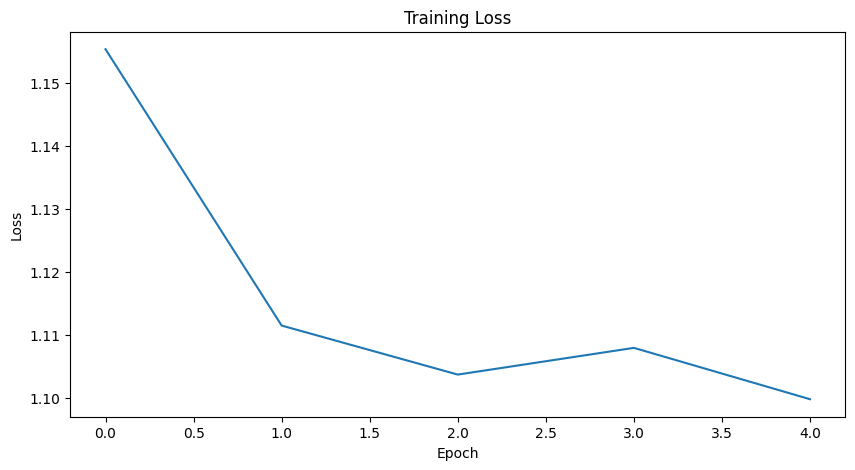

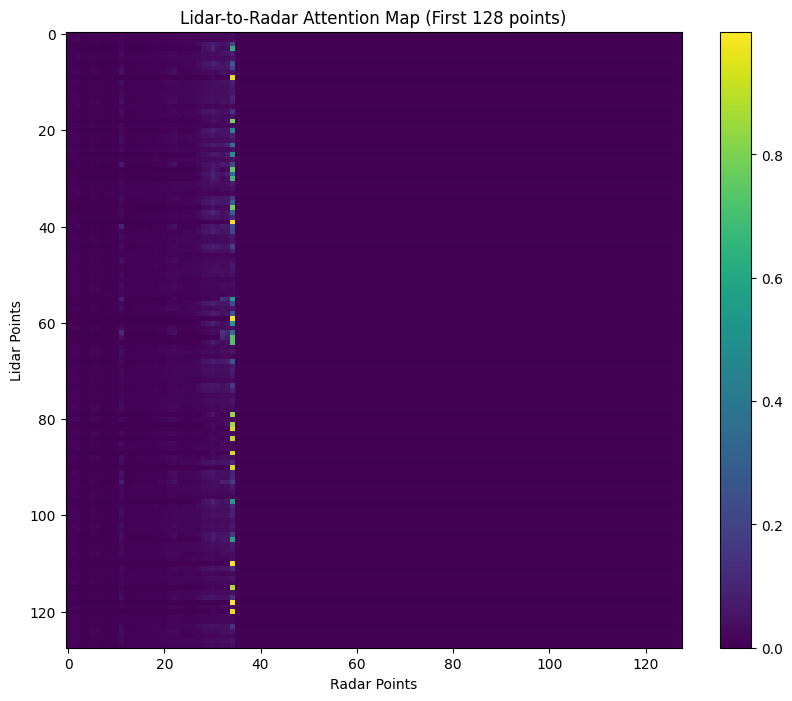

Attention visualization completed successfully.
Training and visualization complete.


In [8]:
import os
import numpy as np
import torch
import torch.nn as nn
import open3d as o3d
import torch.optim as optim
from pyquaternion import Quaternion
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud, RadarPointCloud

# Check file paths and directory structure
def check_nuscenes_paths(nusc):
    """Check and display the NuScenes file structure to debug path issues."""
    print("NuScenes dataroot:", nusc.dataroot)
    print("Version:", nusc.version)
    
    # Check sample path
    if len(nusc.sample) > 0:
        sample = nusc.sample[0]
        print("\nSample info:")
        print(f"Sample token: {sample['token']}")
        
        # Check LIDAR path
        if 'LIDAR_TOP' in sample['data']:
            lidar_token = sample['data']['LIDAR_TOP']
            lidar_data = nusc.get('sample_data', lidar_token)
            lidar_path = os.path.join(nusc.dataroot, lidar_data['filename'])
            print(f"LIDAR file: {lidar_path}")
            print(f"LIDAR file exists: {os.path.exists(lidar_path)}")
        else:
            print("No LIDAR_TOP data in sample")
        
        # Check RADAR path
        if 'RADAR_FRONT' in sample['data']:
            radar_token = sample['data']['RADAR_FRONT']
            radar_data = nusc.get('sample_data', radar_token)
            radar_path = os.path.join(nusc.dataroot, radar_data['filename'])
            print(f"RADAR file: {radar_path}")
            print(f"RADAR file exists: {os.path.exists(radar_path)}")
        else:
            print("No RADAR_FRONT data in sample")
    
    # List available samples
    print("\nAvailable samples directory structure:")
    lidar_dir = os.path.join(nusc.dataroot, 'samples', 'LIDAR_TOP')
    radar_dir = os.path.join(nusc.dataroot, 'samples', 'RADAR_FRONT')
    
    print(f"LIDAR_TOP directory exists: {os.path.exists(lidar_dir)}")
    print(f"RADAR_FRONT directory exists: {os.path.exists(radar_dir)}")
    
    if os.path.exists(lidar_dir):
        print(f"LIDAR files: {len(os.listdir(lidar_dir))}")
        if len(os.listdir(lidar_dir)) > 0:
            print(f"Example LIDAR file: {os.listdir(lidar_dir)[0]}")
    
    if os.path.exists(radar_dir):
        print(f"RADAR files: {len(os.listdir(radar_dir))}")
        if len(os.listdir(radar_dir)) > 0:
            print(f"Example RADAR file: {os.listdir(radar_dir)[0]}")

# Custom dataset to safely load lidar and radar data
class SafeRadarLidarDataset(Dataset):
    def __init__(self, nusc, max_samples=100, n_lidar_points=2048, n_radar_points=512):
        self.nusc = nusc
        self.n_lidar_points = n_lidar_points
        self.n_radar_points = n_radar_points
        
        # Get all samples with valid paths
        self.valid_samples = []
        count = 0
        
        for sample in nusc.sample:
            if count >= max_samples:
                break
                
            if 'LIDAR_TOP' in sample['data'] and 'RADAR_FRONT' in sample['data']:
                lidar_data = nusc.get('sample_data', sample['data']['LIDAR_TOP'])
                radar_data = nusc.get('sample_data', sample['data']['RADAR_FRONT'])
                
                lidar_path = os.path.join(nusc.dataroot, lidar_data['filename'])
                radar_path = os.path.join(nusc.dataroot, radar_data['filename'])
                
                if os.path.exists(lidar_path) and os.path.exists(radar_path):
                    self.valid_samples.append({
                        'sample': sample,
                        'lidar_path': lidar_path,
                        'radar_path': radar_path
                    })
                    count += 1
        
        print(f"Found {len(self.valid_samples)} valid samples with both lidar and radar data")
    
    def __len__(self):
        return len(self.valid_samples)
    
    def __getitem__(self, idx):
        sample_data = self.valid_samples[idx]
        
        # Load lidar data
        lidar_pc = LidarPointCloud.from_file(sample_data['lidar_path'])
        
        # Load radar data
        radar_pc = RadarPointCloud.from_file(sample_data['radar_path'])
        
        # Get calibration data for coordinate transformation
        lidar_token = sample_data['sample']['data']['LIDAR_TOP']
        radar_token = sample_data['sample']['data']['RADAR_FRONT']
        
        lidar_data = self.nusc.get('sample_data', lidar_token)
        radar_data = self.nusc.get('sample_data', radar_token)
        
        lidar_cs_record = self.nusc.get('calibrated_sensor', lidar_data['calibrated_sensor_token'])
        radar_cs_record = self.nusc.get('calibrated_sensor', radar_data['calibrated_sensor_token'])
        
        # Transform radar to lidar coordinate frame
        # Convert radar to vehicle frame, then to lidar frame
        radar_pc.rotate(Quaternion(radar_cs_record['rotation']).rotation_matrix)
        radar_pc.translate(np.array(radar_cs_record['translation']))
        
        # Inverse transform from vehicle to lidar
        radar_pc.translate(-np.array(lidar_cs_record['translation']))
        radar_pc.rotate(Quaternion(lidar_cs_record['rotation']).rotation_matrix.T)
        
        # Process point clouds
        lidar_points = lidar_pc.points.T  # [N, 4] - x, y, z, intensity
        radar_points = radar_pc.points.T  # [M, 18] in NuScenes format
        
        # Extract relevant radar features (position, RCS, velocity)
        radar_features = np.column_stack([
            radar_points[:, :3],  # x, y, z
            radar_points[:, 3],   # RCS (Radar Cross Section)
            radar_points[:, 8:10]  # vx, vy (velocity)
        ])
        
        # Sample or pad to fixed size
        if lidar_points.shape[0] > self.n_lidar_points:
            idx = np.random.choice(lidar_points.shape[0], self.n_lidar_points, replace=False)
            lidar_points = lidar_points[idx]
        elif lidar_points.shape[0] < self.n_lidar_points:
            # Pad with zeros
            padding = np.zeros((self.n_lidar_points - lidar_points.shape[0], lidar_points.shape[1]))
            lidar_points = np.vstack([lidar_points, padding])
        
        if radar_features.shape[0] > self.n_radar_points:
            idx = np.random.choice(radar_features.shape[0], self.n_radar_points, replace=False)
            radar_features = radar_features[idx]
        elif radar_features.shape[0] < self.n_radar_points:
            # Pad with zeros
            padding = np.zeros((self.n_radar_points - radar_features.shape[0], radar_features.shape[1]))
            radar_features = np.vstack([radar_features, padding])
        
        # Create dummy labels for demonstration (3 classes)
        dummy_label = np.zeros(3)
        dummy_label[np.random.randint(0, 3)] = 1  # Random one-hot label
        
        return torch.FloatTensor(lidar_points), torch.FloatTensor(radar_features), torch.FloatTensor(dummy_label)

# Point feature encoder network
class PointNetEncoder(nn.Module):
    def __init__(self, in_channels, out_channels=128):
        super(PointNetEncoder, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, out_channels, 1)
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(out_channels)
        
    def forward(self, x):
        # x shape: [B, N, C]
        x = x.transpose(1, 2)  # [B, C, N]
        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = torch.relu(self.bn3(self.conv3(x)))
        x = x.transpose(1, 2)  # [B, N, C]
        return x

# Multi-head cross-attention module
class MultiHeadCrossAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super(MultiHeadCrossAttention, self).__init__()
        self.mha = nn.MultiheadAttention(embed_dim, num_heads)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.ReLU(),
            nn.Linear(embed_dim * 4, embed_dim)
        )
        
    def forward(self, query, key_value):
        # q: [B, N, C], kv: [B, M, C]
        query = query.transpose(0, 1)  # [N, B, C]
        key_value = key_value.transpose(0, 1)  # [M, B, C]
        
        # Cross attention
        attn_output, _ = self.mha(query, key_value, key_value)
        attn_output = attn_output.transpose(0, 1)  # [B, N, C]
        
        # Add & norm
        out1 = self.norm1(query.transpose(0, 1) + attn_output)
        
        # FFN
        ffn_output = self.ffn(out1)
        out2 = self.norm2(out1 + ffn_output)
        
        return out2

# Complete radar-lidar fusion model
class RadarLidarFusionModel(nn.Module):
    def __init__(self, lidar_channels=4, radar_channels=6, hidden_dim=128, num_heads=4, num_classes=3):
        super(RadarLidarFusionModel, self).__init__()
        
        # Point feature extractors
        self.lidar_encoder = PointNetEncoder(lidar_channels, hidden_dim)
        self.radar_encoder = PointNetEncoder(radar_channels, hidden_dim)
        
        # Cross-attention modules
        self.lidar_to_radar = MultiHeadCrossAttention(hidden_dim, num_heads)
        self.radar_to_lidar = MultiHeadCrossAttention(hidden_dim, num_heads)
        
        # Fusion
        self.fusion_layer = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        
        # Output layer
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, lidar_points, radar_points):
        # Encode point features
        lidar_features = self.lidar_encoder(lidar_points)  # [B, N, C]
        radar_features = self.radar_encoder(radar_points)  # [B, M, C]
        
        # Cross-attention
        lidar_enhanced = self.lidar_to_radar(lidar_features, radar_features)
        radar_enhanced = self.radar_to_lidar(radar_features, lidar_features)
        
        # Global feature pooling (max pooling)
        lidar_global = torch.max(lidar_enhanced, dim=1)[0]  # [B, C]
        radar_global = torch.max(radar_enhanced, dim=1)[0]  # [B, C]
        
        # Concatenate and fuse
        fused_features = torch.cat([lidar_global, radar_global], dim=1)  # [B, 2C]
        fused_features = self.fusion_layer(fused_features)  # [B, C]
        
        # Classification
        output = self.classifier(fused_features)
        
        return output, fused_features

# Training function
def train_fusion_model(dataset, num_epochs=5, batch_size=4, learning_rate=0.001):
    # Create dataloader
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    
    # Initialize model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = RadarLidarFusionModel().to(device)
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Training loop
    train_losses = []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for i, (lidar_points, radar_points, labels) in enumerate(dataloader):
            lidar_points = lidar_points.to(device)
            radar_points = radar_points.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs, _ = model(lidar_points, radar_points)
            loss = criterion(outputs, labels)
            
            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            if (i + 1) % 5 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(dataloader)}], Loss: {loss.item():.4f}')
        
        epoch_loss = running_loss / len(dataloader)
        train_losses.append(epoch_loss)
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')
    
    return model, train_losses

# Fixed visualize_attention function
def visualize_attention(model, lidar_points, radar_points):
    """Visualize cross-attention between lidar and radar points."""
    device = next(model.parameters()).device
    
    # Add batch dimension if needed
    if lidar_points.dim() == 2:
        lidar_points = lidar_points.unsqueeze(0)
    if radar_points.dim() == 2:
        radar_points = radar_points.unsqueeze(0)
    
    lidar_points = lidar_points.to(device)
    radar_points = radar_points.to(device)
    
    model.eval()
    with torch.no_grad():
        # Get encoded features
        lidar_features = model.lidar_encoder(lidar_points)  # [B, N, C]
        radar_features = model.radar_encoder(radar_points)  # [B, M, C]
        
        # Using the multi-head attention directly from the model
        # We'll use the first few points for visualization (to keep the attention map manageable)
        max_points = min(128, lidar_features.size(1), radar_features.size(1))
        lidar_subset = lidar_features[:, :max_points, :]
        radar_subset = radar_features[:, :max_points, :]
        
        # Use the MultiheadAttention module to calculate attention
        # We need to reformat for the MHA input requirements
        lidar_query = lidar_subset.transpose(0, 1)  # [N, B, C]
        radar_kv = radar_subset.transpose(0, 1)     # [M, B, C]
        
        # Get attention weights using the multihead attention module
        _, attn_weights = model.lidar_to_radar.mha(
            lidar_query, 
            radar_kv, 
            radar_kv, 
            need_weights=True, 
            average_attn_weights=False
        )
        
        # Average attention weights across heads
        avg_attn = attn_weights.mean(dim=0).cpu().numpy()  # [B, N, M]
    
    # Visualize attention map (for the first sample in batch)
    plt.figure(figsize=(10, 8))
    plt.imshow(avg_attn[0], cmap='viridis')
    plt.colorbar()
    plt.title(f'Lidar-to-Radar Attention Map (First {max_points} points)')
    plt.xlabel('Radar Points')
    plt.ylabel('Lidar Points')
    plt.savefig('attention_map.png')
    plt.show()
    
    return avg_attn

# You might also want to improve the main function to handle the visualization error
def main():
    # Initialize NuScenes
    nusc = NuScenes(
        version='v1.0-trainval',
        dataroot='/kaggle/input/nuscenes/v1.0-trainval',
        verbose=True
    )
    
    # Check paths to debug
    check_nuscenes_paths(nusc)
    
    # Create dataset with existing files only
    dataset = SafeRadarLidarDataset(nusc, max_samples=50)
    
    if len(dataset) == 0:
        print("No valid data samples found. Please check the file paths.")
        return
    
    # Get a sample to check
    lidar_points, radar_points, _ = dataset[0]
    print(f"Lidar points shape: {lidar_points.shape}")
    print(f"Radar points shape: {radar_points.shape}")
    
    # Train model
    model, losses = train_fusion_model(dataset, num_epochs=5, batch_size=4)
    
    # Save model
    torch.save(model.state_dict(), 'radar_lidar_fusion_model.pth')
    
    # Plot training loss
    plt.figure(figsize=(10, 5))
    plt.plot(losses)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.savefig('training_loss.png')
    plt.show()
    
    # Visualize attention for a sample
    if len(dataset) > 0:
        try:
            lidar_sample, radar_sample, _ = dataset[0]
            attn_map = visualize_attention(model, lidar_sample, radar_sample)
            print("Attention visualization completed successfully.")
        except Exception as e:
            print(f"Attention visualization failed: {e}")
            print("Continuing with the rest of the execution...")
    
    print("Training and visualization complete.")
    
    # Return model for further use
    return model, dataset


if __name__ == "__main__":
    main()